# Lecture 8 — Neural Value Function Iteration

**Computational Methods for Heterogeneous-Agent Macro**

Jeffrey Sun

## 1. Setup

In [1]:
using Pkg
Pkg.activate("..")
Pkg.instantiate()

using HouseholdStages
using Flux
using Flux: Chain, Dense, swish, Adam, withgradient
using Printf
using Statistics
using LinearAlgebra
using Random: MersenneTwister, seed!
using Plots

  Activating project at `~/projects/research/CV is all you need`


## 2. The Krusell-Smith setup

The **Krusell-Smith** model is Aiyagari with an **aggregate** Markov process for TFP $A$.

This means that the ``perfect-foresight'' method we used for the MIT shock will no longer work.

With stochastic aggregate productivity $Z_t$, prices $r_t, w_t$ depend on $(Z_t, K_t)$. Now, if the household could anticipate $K_{t+1}$ from $K_t$ alone, then we could treat $K_t$ much like just another idiosyncratic state variable. (This is basically the trick used by so-called ``block-recursive'' models.)

But sadly, no such luck here: In this case, $K_{t+1}$ is the integral of *all* households' savings choices, which (due to heterogeneity) depend on the entire wealth distribution $\Lambda_t$.

So the agent's own state space has to include $\Lambda_t$ to make truly rational (i.e. rational-expectations) decisions:
$$V(b, z; \Lambda, Z) = \max_{c, b'} u(c) + \beta\, \mathbb{E}[V(b', z'; \Lambda', Z') \mid z, Z].$$

But a grid over **all possible values** of $\Lambda_t$ is infeasible. We need some kind of dimension reduction.

Here, we cover two such methods. The latter is my own contribution:

- **§3 — Krusell-Smith (1998):** assume agents track only the first moment $K_t$ and forecast $K_{t+1}$ from a parametric log-linear rule. Solve the implied 4D VFI, simulate, refit the rule. Approximate aggregation makes this work.
- **§4 — CVIAYN:** parameterise $V_\theta(b, z, \Lambda, Z)$ directly with a neural network that conditions on the full distribution $\Lambda$ via a learned generalized moment. Drop the ALM, drop the regression, train against the outer Bellman residual.

This notebook and the previous demonstrate two methods solving the same **Krusell-Smith** model.

nVFI is not dramatically better than the K--S method on the K--S model. Indeed, the K--S method does pretty well! But nVFI is more general.

We start by building the K--S model.

### 2.1 Parameters

In [2]:
@kwdef struct KSParams
    β::Float64 = 0.96
    γ::Float64 = 1.0
    α::Float64 = 0.36
    δ::Float64 = 0.025
    # Idiosyncratic productivity z (unemployed / employed)
    z_grid::Vector{Float64} = [0.07, 1.0]
    Π_z::Matrix{Float64}    = [0.6   0.4;
                               0.05  0.95]
    # Aggregate TFP Z (bad / good)
    Z_vals::Vector{Float64} = [0.99, 1.01]
    Π_Z::Matrix{Float64}    = [0.875 0.125;
                               0.125 0.875]
    # Wealth grid
    N_b::Int       = 80
    b_min::Float64 = 0.0
    b_max::Float64 = 80.0
    # K grid (for the K-S 4D VFI; not used by CVIAYN)
    N_K::Int       = 5
    K_min::Float64 = 10.5
    K_max::Float64 = 14.5
end

KSParams

### 2.2 Prices and effective labour

Cobb-Douglas production with TFP $Z$ and effective labour $L$:
$$R(Z, K) = \alpha\, Z\, (K/L)^{\alpha-1} + 1 - \delta, \qquad w(Z, K) = (1-\alpha)\, Z\, (K/L)^\alpha.$$

Effective labour is the stationary-distribution average of $z$. It is constant in this model since $\Pi_z$ is independent of $Z$.

In [3]:
function markov_stationary_mean(Π_z::AbstractMatrix, z_grid::AbstractVector)
    v = real.(eigvecs(Π_z')[:, end])
    return z_grid ⋅ (v ./ sum(v))
end

function ks_prices(K, Z, p::KSParams)
    L = markov_stationary_mean(p.Π_z, p.z_grid)
    R = p.α * Z * (K/L)^(p.α - 1) + 1 - p.δ
    w = (1 - p.α) * Z * (K/L)^p.α
    return (; R, w)
end

ks_prices (generic function with 1 method)

### 2.3 The inner household chain (3 stages)

The within-period block is the same as Aiyagari: `z_shock ∘ income ∘ savings`.

In [4]:
_u_crra(c, ::Val{1}) = log(c)
_u_crra(c, ::Val{1.0}) = log(c)
_u_crra(c, ::Val{σ}) where σ = (c^(1 - σ)) / (1 - σ)
u_crra(c, valσ::Val) = c < 0 ? -Inf : _u_crra(c, valσ)

"Three-stage household chain: z_shock ∘ income ∘ savings. Prices are read from env."
function ks_household(p::KSParams)
    # Define layout: axis 1 (wealth) is continuous, axis 2 (z) is discrete.
    layout = StateLayout(
        StateAxis(:wealth, continuous_grid(p.b_min, p.b_max; length=p.N_b, spacing=:log)),
        StateAxis(:z, p.z_grid),
    )

    # Define the three stages.
    z_shock = MarkovStage(layout; axis=:z, transition=p.Π_z)
    income  = WealthChangeStage(layout; wealth_post=(cell; env) -> env.R * cell.wealth + env.w * cell.z)
    savings = ConsumptionSavingsStage(layout; β=p.β, utility=(cell, c; env) -> u_crra(c, Val(p.γ)), monotone_search=:divide_conquer)

    # Build the household chain and define a moment.
    hh = z_shock ∘ income ∘ savings
    return define_moments!(hh; K_supplied=at_end(integrand=:wealth, reduce=sum))
end

ks_household

### 2.4 Deterministic Aiyagari SS at $Z = 1$

Before adding aggregate uncertainty, find the deterministic steady state $\bar K$ at $Z = 1$ using tatonnement.

In [5]:
"Solve the deterministic Aiyagari steady state at given Z via damped tatonnement on K."
function aiyagari_steady_state_at_Z(p::KSParams; Z=1.0, K_init=12.0, update_speed=0.05, rtol=1e-2, maxiter=200, verbosity=0)
    local V, Λ
    hh = ks_household(p)
    K  = K_init
    V, Λ = nothing, nothing

    err = Inf
    iters = 0
    while err >= rtol
        env = make_env(hh; ks_prices(K, Z, p)...)
        (;V, Λ, moments) = solve_steady_state_given_env!(hh, env; V_init=V, Λ_init=Λ, lambda_tol=1e-5, lambda_maxiter=50_000)
        K_supplied = moments.K_supplied
        err = abs(K_supplied - K) / K
        K = (1 - update_speed)*K + update_speed*K_supplied

        verbosity >= 1 && @printf "  iter %d: K = %.4f → K_supplied = %.4f, err = %.2e\n" iters K K_supplied err
        iters = iters + 1
        iters > maxiter && error("aiyagari_steady_state_at_Z did not converge in $maxiter iterations")
    end

    return (; K, V, Λ, iters)
end

aiyagari_steady_state_at_Z

## 4. Solving via CVIAYN

Here, we train a neural network, $\widehat{V}^{\mathrm{end}}_\theta$, to approximate the value function, conditional on the full population distribution $\Lambda$.

### 4.1 The neural network $V_\theta$: a generalized-moment architecture

The particular architecture we choose starts by factoring $V_\theta(b, z, \Lambda, Z)$ into four sub-nets, mirroring Han-Yang-E (2025):

[Description here.]

In [6]:
p = KSParams()

const N_z = length(p.z_grid)
const N_Z = length(p.Z_vals)

# Pre-build the (2, N_b * N_z) feature matrix once. Each column is the
# normalised (b, z) coordinates of one cell.
function build_hh_feat(p::KSParams)
    b_norm = collect(range(0f0, 1f0; length=p.N_b))
    z_norm = collect(range(0f0, 1f0; length=length(p.z_grid)))
    feat = zeros(Float32, 2, p.N_b * length(p.z_grid))
    col = 1
    for j in 1:length(p.z_grid), i in 1:p.N_b
        feat[1, col] = b_norm[i]
        feat[2, col] = z_norm[j]
        col += 1
    end
    return feat
end

const HH_FEAT = build_hh_feat(p)
const N_CELLS = size(HH_FEAT, 2)

# Pre-build one-hot Z rows for each Z_idx, shape (N_Z, N_CELLS), so we can
# vcat directly with the (mid, N_CELLS) hidden features in V_post.
const Z_ROWS = [repeat(Float32.(1:N_Z .== Z_idx), 1, N_CELLS) for Z_idx in 1:N_Z]

2-element Vector{Matrix{Float32}}:
 [1.0 1.0 … 1.0 1.0; 0.0 0.0 … 0.0 0.0]
 [0.0 0.0 … 0.0 0.0; 1.0 1.0 … 1.0 1.0]

In [7]:
struct VNet{A, P, G, V}
    pop_agg_net :: A    # (b, z) → gm_dim         per-cell embedding for GM
    V_pre       :: P    # (b, z) → mid            per-cell features for V head
    gm_post     :: G    # gm_dim → mid            project GM to mid space
    V_post      :: V    # mid + N_Z → 1           combine + Z, read off V_end
end

function VNet(; gm_dim=16, mid=32, seed=9483, v_bias=20f0)
    seed!(seed)
    pop_agg_net = Chain(Dense(2 => mid, swish), Dense(mid => mid, swish), Dense(mid => gm_dim))
    V_pre       = Chain(Dense(2 => mid, swish), Dense(mid => mid, swish), Dense(mid => mid, swish))
    gm_post     = Chain(Dense(gm_dim => mid), Dense(mid => mid, swish))
    V_post      = Chain(Dense(mid + N_Z => mid, swish), Dense(mid => mid, swish), Dense(mid => 1))
    V_post.layers[end].bias .= v_bias  # initialise to roughly V_ss mean
    return VNet(pop_agg_net, V_pre, gm_post, V_post)
end

Flux.@layer VNet

function (net::VNet)(Λ::AbstractMatrix, Z_idx::Int, p::KSParams)
    pop_emb = net.pop_agg_net(HH_FEAT)          # (gm_dim, N_CELLS)
    gm      = pop_emb * Float32.(vec(Λ))        # (gm_dim,)   pop-weighted average
    h_pre   = net.V_pre(HH_FEAT)                # (mid, N_CELLS)
    h_gm    = net.gm_post(gm)                   # (mid,)
    h       = h_pre .+ h_gm                     # broadcast → (mid, N_CELLS)
    pred    = net.V_post(vcat(h, Z_ROWS[Z_idx])) # (1, N_CELLS)
    return reshape(pred, p.N_b, length(p.z_grid))
end

### 4.2 One inner solve under $V_\theta$

Given an aggregate state $(\Lambda, Z)$:

1. Evaluate $V_\theta(\Lambda, Z)$ to get an `N_b × N_z` array of $V^{\mathrm{end}}$ values.
2. Build `env` at prices $(R, w) = $ `ks_prices(K(Λ), Z, p)`, where $K(\Lambda) = \int b\, d\Lambda$.
3. One backward sweep through the 3-stage chain `ks_household` returns $V^{\mathrm{start}}$ and seats the savings policy.

This is $\Phi_V$ from the CVIAYN paper.

In [8]:
"Wealth integral against a 2D (b, z) distribution."
function integrate_K(hh, Λ::AbstractMatrix)
    b_grid = axisvalues(input_layout(hh).axes[1])
    return sum(Λ[i, j] * b_grid[i] for i in axes(Λ, 1), j in axes(Λ, 2))
end

"One backward sweep through the 3-stage chain at the given (Λ, Z) under V_θ."
function inner_solve_backward(hh, vnet::VNet, Λ::AbstractMatrix, Z_idx::Int, p::KSParams)
    V_end = Float64.(vnet(Λ, Z_idx, p))
    env   = make_env(hh; ks_prices(integrate_K(hh, Λ), p.Z_vals[Z_idx], p)...)
    return backward!(hh, V_end, env)
end

ss = aiyagari_steady_state_at_Z(p; verbosity=1)
K_bar, Λ_ss, V_ss = ss.K, ss.Λ, ss.V
hh = ks_household(p)

vnet = VNet()
V0 = vnet(Λ_ss, 1, p)
@printf "VNet output at (Λ_ss, Z=1): shape = %s, range = [%.3f, %.3f]\n" string(size(V0)) minimum(V0) maximum(V0)

V_start_demo = inner_solve_backward(hh, vnet, Λ_ss, 1, p)
@printf "Inner backward at (Λ_ss, Z=bad): V_start shape = %s, range = [%.3f, %.3f]\n" string(size(V_start_demo)) minimum(V_start_demo) maximum(V_start_demo)

  iter 0: K = 12.8410 → K_supplied = 28.8200, err = 1.40e+00
  iter 1: K = 13.2660 → K_supplied = 21.3415, err = 6.62e-01
  iter 2: K = 13.6605 → K_supplied = 21.1557, err = 5.95e-01
  iter 3: K = 13.9688 → K_supplied = 19.8263, err = 4.51e-01
  iter 4: K = 14.1889 → K_supplied = 18.3699, err = 3.15e-01
  iter 5: K = 14.1109 → K_supplied = 12.6291, err = 1.10e-01
  iter 6: K = 14.0343 → K_supplied = 12.5794, err = 1.09e-01
  iter 7: K = 13.9595 → K_supplied = 12.5381, err = 1.07e-01
  iter 8: K = 13.8905 → K_supplied = 12.5798, err = 9.88e-02
  iter 9: K = 13.8240 → K_supplied = 12.5605, err = 9.57e-02
  iter 10: K = 13.7597 → K_supplied = 12.5375, err = 9.31e-02
  iter 11: K = 13.7462 → K_supplied = 13.4895, err = 1.96e-02
  iter 12: K = 13.7318 → K_supplied = 13.4593, err = 2.09e-02
  iter 13: K = 13.7161 → K_supplied = 13.4173, err = 2.29e-02
  iter 14: K = 13.6994 → K_supplied = 13.3820, err = 2.44e-02
  iter 15: K = 13.6955 → K_supplied = 13.6206, err = 5.75e-03
VNet output at (Λ_

### 4.3 The lookahead operator $\mathcal{L} V_\theta$

For a single sampled $\Lambda^{\mathrm{start}}_i$ with aggregate index $Z_i$:

1. Evaluate $V_\theta(\Lambda^{\mathrm{start}}_i, Z_i)$ to get $V^{\mathrm{end}}$ — the agent's current belief about end-of-period continuation values.
2. Push $\Lambda^{\mathrm{start}}_i$ forward one period through $\Phi$ to get $\Lambda^{\mathrm{end}}_i$.
3. For each next-period aggregate state $Z_{\mathrm{next}}$, run $\Phi_V$ at $(\Lambda^{\mathrm{end}}_i, Z_{\mathrm{next}})$ to get $V^{\mathrm{start}}_{\mathrm{next}}$.
4. Take expectation over $Z_{\mathrm{next}}$ using $\Pi_Z[Z_i, \cdot]$.

In this setup $\Omega(\Lambda^{\mathrm{end}}, Z')$ is the identity — the aggregate shock $Z'$ affects next-period prices but not $\Lambda$ at the period boundary. So $\Lambda^{\mathrm{start}}_{i+1} = \Lambda^{\mathrm{end}}_i$. The result is the **lookahead label** $\widehat{V}^{\mathrm{end}}_i \equiv (\mathcal{L} V_\theta)(\Lambda^{\mathrm{start}}_i, Z_i)$.

In [9]:
"Compute the lookahead label LV_θ(Λ_start, Z). Returns V_end_label and Λ_end."
function lookahead(hh, vnet::VNet, Λ_start::AbstractMatrix, Z_idx::Int, p::KSParams)
    V_end_now = Float64.(vnet(Λ_start, Z_idx, p))
    env_now   = make_env(hh; ks_prices(integrate_K(hh, Λ_start), p.Z_vals[Z_idx], p)...)
    backward!(hh, V_end_now, env_now)                  # seats savings policy
    Λ_end = forward!(hh, Λ_start)

    V_end_label = zeros(Float64, p.N_b, length(p.z_grid))
    for Z_next in 1:N_Z
        V_start_next = inner_solve_backward(hh, vnet, Λ_end, Z_next, p)
        V_end_label .+= p.Π_Z[Z_idx, Z_next] .* V_start_next
    end
    return (; V_end_label, Λ_end)
end

lookahead

### 4.4 Outer Bellman residual loss

For a batch of samples $\{(\Lambda^{\mathrm{start}}_i, Z_i)\}$, compute the lookahead label $\widehat{V}^{\mathrm{end}}_i$ once *outside* `withgradient`, then fit $V_\theta$ to it in mean-square. This is the standard semi-gradient treatment — we don't differentiate through $\Phi$.

In [10]:
"Run the lookahead operator on each sample. Returns a vector of (Λ, Z_idx, target) tuples."
function build_targets(hh, vnet::VNet, batch, p::KSParams)
    targets = NamedTuple{(:Λ, :Z_idx, :target), Tuple{Matrix{Float64}, Int, Matrix{Float32}}}[]
    for (Λ_start, Z_idx) in batch
        out = lookahead(hh, vnet, Λ_start, Z_idx, p)
        push!(targets, (; Λ=copy(Λ_start), Z_idx, target=Float32.(out.V_end_label)))
    end
    return targets
end

"Outer Bellman residual loss on a batch of (Λ, Z, target) tuples."
function bellman_residual_loss(vnet::VNet, targets, p::KSParams)
    L = 0f0
    for (Λ, Z_idx, target) in targets
        pred  = vnet(Λ, Z_idx, p)
        scale = max(var(target), 1f-6)             # normalise by target scale
        L    += sum((pred .- target).^2) / (length(pred) * scale)
    end
    return L / length(targets)
end

bellman_residual_loss

### 4.5 Sampling $\Lambda^{\mathrm{start}}$ by MCMC

Simulate the model under the *current* $V_\theta$, discard burn-in, subsample. The sampler tracks the network — early in training, samples are drawn from the trajectory induced by an under-trained network; the distribution improves with $\theta$.

In [11]:
"Sample Z_{t+1} | Z_t from the aggregate Markov chain."
function sample_Z(Z_idx, Π_Z, rng)
    u = rand(rng)
    s = 0.0
    for j in eachindex(view(Π_Z, Z_idx, :))
        s += Π_Z[Z_idx, j]
        u <= s && return j
    end
    return size(Π_Z, 2)
end

"Simulate one period forward under V_θ at realised (Λ_t, Z_t). Reseats the savings policy."
function sim_one_step(hh, vnet::VNet, Λ::AbstractMatrix, Z_idx::Int, p::KSParams)
    V_end = Float64.(vnet(Λ, Z_idx, p))
    env   = make_env(hh; ks_prices(integrate_K(hh, Λ), p.Z_vals[Z_idx], p)...)
    backward!(hh, V_end, env)
    return forward!(hh, Λ)
end

"MCMC-style sample of (Λ_start, Z) along the ergodic path induced by V_θ."
function sample_ergodic(hh, vnet::VNet, p::KSParams; T=200, burn=100, every=2, rng=MersenneTwister(8421))
    Λ     = copy(Λ_ss)
    Z_idx = 1
    batch = Tuple{Matrix{Float64}, Int}[]
    for t in 1:T
        Λ     = sim_one_step(hh, vnet, Λ, Z_idx, p)
        Z_idx = sample_Z(Z_idx, p.Π_Z, rng)
        if t > burn && (t - burn) % every == 0
            push!(batch, (copy(Λ), Z_idx))
        end
    end
    return batch
end

sample_ergodic

### 4.6 Pretrain on the deterministic $V_{\mathrm{ss}}$

A randomly-initialised $V_\theta$ often produces within-period solves that fail numerically (consumption tries to go off-grid, savings policy degenerates). The cheap fix: pretrain $V_\theta$ to match the deterministic-SS value function $V_{\mathrm{ss}}$ across a cloud of $\Lambda$'s (perturbed $\Lambda_{\mathrm{ss}}$) and across all $Z$'s. The network ends up on a sane manifold; the residual training loop refines from there.

The point is *not* that $V_{\mathrm{ss}}$ is the right answer at any $\Lambda$ — it isn't, except by coincidence at $\Lambda = \Lambda_{\mathrm{ss}}, Z = 1$. The point is that it's a sensible *constant* baseline, which gets the network into the right scale and shape before real training.

In [12]:
"Multiplicative-noise perturbation of Λ with renormalisation."
function perturb_Λ(Λ::AbstractMatrix, σ, rng)
    Λp = Λ .* (1 .+ σ .* randn(rng, size(Λ)))
    Λp = max.(Λp, 0)
    return Λp ./ sum(Λp)
end

"Pretrain V_θ on V_ss replicated across a cloud of (Λ, Z) inputs. Returns the loss history."
function pretrain_to_ss!(vnet::VNet, V_ss_target, p::KSParams; epochs=300, lr=5e-3, n_Λ=6, σ=0.10, seed=4747)
    opt    = Flux.setup(Adam(lr), vnet)
    target = Float32.(V_ss_target)
    rng    = MersenneTwister(seed)
    hist   = Float64[]
    for epoch in 1:epochs
        Λ_cloud = [perturb_Λ(Λ_ss, σ, rng) for _ in 1:n_Λ]
        loss, grads = withgradient(vnet) do net
            L = 0f0
            for Λ in Λ_cloud, Z_idx in 1:N_Z
                pred = net(Λ, Z_idx, p)
                L += sum((pred .- target).^2)
            end
            L / (n_Λ * N_Z * length(target))
        end
        Flux.update!(opt, vnet, grads[1])
        push!(hist, Float64(loss))
    end
    return hist
end

println("Pretraining V_θ on V_ss across a Λ-cloud...")
@time pre_hist = pretrain_to_ss!(vnet, V_ss, p; epochs=300)
@printf "Pretrain loss: %.4e → %.4e (over %d epochs)\n" pre_hist[1] pre_hist[end] length(pre_hist)

Pretraining V_θ on V_ss across a Λ-cloud...
 28.103704 seconds (59.74 M allocations: 5.849 GiB, 3.16% gc time, 85.32% compilation time: <1% of which was recompilation)
Pretrain loss: 7.6335e+01 → 4.8556e-02 (over 300 epochs)


### 4.7 The training loop

One epoch = sample a fresh batch under the current $V_\theta$, compute the lookahead labels (stop-gradient), take one Adam step on the squared residual.

In [14]:
"Outer-Bellman-residual training loop. Returns the loss history."
function train!(vnet::VNet, hh, p::KSParams; epochs=50, lr=1e-3, T=200, burn=100, every=4)
    opt  = Flux.setup(Adam(lr), vnet)
    hist = Float64[]
    rng  = MersenneTwister(1729)
    for epoch in 1:epochs
        batch   = sample_ergodic(hh, vnet, p; T, burn, every, rng=MersenneTwister(rand(rng, UInt32)))
        targets = build_targets(hh, vnet, batch, p)
        loss, grads = withgradient(vnet) do net
            bellman_residual_loss(net, targets, p)
        end
        Flux.update!(opt, vnet, grads[1])
        push!(hist, Float64(loss))
        (epoch == 1 || epoch % 10 == 0) &&
            @printf "  epoch %3d / %3d: loss = %.4e (batch = %d)\n" epoch epochs loss length(batch)
    end
    return hist
end

train!

### 4.8 Run training loop

**NOTE:** We are using a small neural network for demonstration purposes.

In [15]:
train_hist = train!(vnet, hh, p; epochs=2_000)

  epoch   1 / 2000: loss = 1.3032e-03 (batch = 25)
  epoch  10 / 2000: loss = 1.8272e-04 (batch = 25)
  epoch  20 / 2000: loss = 3.9152e-04 (batch = 25)
  epoch  30 / 2000: loss = 2.7606e-04 (batch = 25)
  epoch  40 / 2000: loss = 4.4108e-04 (batch = 25)
  epoch  50 / 2000: loss = 2.0345e-04 (batch = 25)
  epoch  60 / 2000: loss = 2.1435e-04 (batch = 25)
  epoch  70 / 2000: loss = 1.6612e-04 (batch = 25)
  epoch  80 / 2000: loss = 1.2731e-04 (batch = 25)
  epoch  90 / 2000: loss = 1.0799e-04 (batch = 25)
  epoch 100 / 2000: loss = 1.3585e-04 (batch = 25)
  epoch 110 / 2000: loss = 1.0639e-04 (batch = 25)
  epoch 120 / 2000: loss = 1.3492e-04 (batch = 25)
  epoch 130 / 2000: loss = 2.1883e-04 (batch = 25)
  epoch 140 / 2000: loss = 8.7109e-05 (batch = 25)
  epoch 150 / 2000: loss = 1.0017e-03 (batch = 25)
  epoch 160 / 2000: loss = 2.7876e-04 (batch = 25)
  epoch 170 / 2000: loss = 6.0451e-04 (batch = 25)
  epoch 180 / 2000: loss = 2.7890e-04 (batch = 25)
  epoch 190 / 2000: loss = 1.98

2000-element Vector{Float64}:
 0.001303238095715642
 0.00025924929650500417
 0.00027146650245413184
 0.00023394655727315694
 0.00017558597028255463
 0.0001473676529712975
 0.00018257419287692755
 0.0002142580779036507
 0.00021693693997804075
 0.00018272142915520817
 ⋮
 0.0002087995526380837
 0.0005915443180128932
 0.0005487221060320735
 0.0011009813752025366
 0.0007572837057523429
 0.00048628266085870564
 0.0024393764324486256
 0.0005557030090130866
 0.0008353617158718407

### 4.8 Reading the loss curve

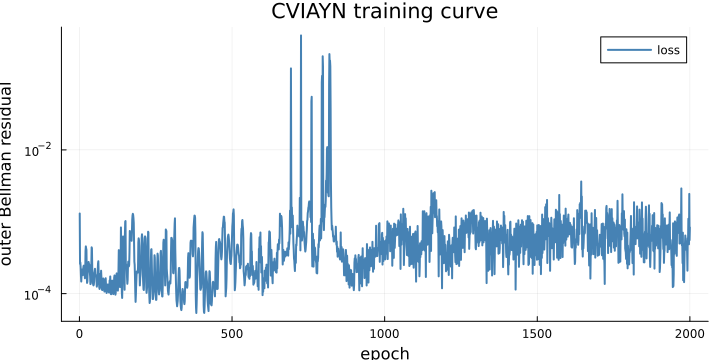

In [16]:
plot(train_hist; yaxis=:log, lw=2, color=:steelblue,
     xlabel="epoch", ylabel="outer Bellman residual",
     title="CVIAYN training curve",
     label="loss", size=(720, 360), legend=:topright)

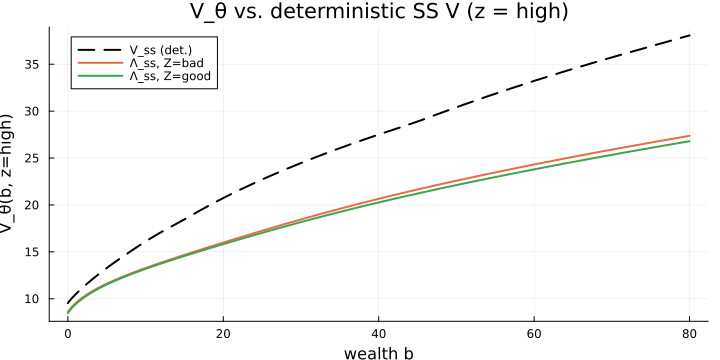

In [18]:
rng_show = MersenneTwister(12345)
b_grid   = axisvalues(input_layout(hh).axes[1])

plt = plot(; xlabel="wealth b", ylabel="V_θ(b, z=high)",
           title="V_θ vs. deterministic SS V (z = high)",
           size=(720, 360))
plot!(plt, b_grid, V_ss[:, end]; lw=2, color=:black, ls=:dash, label="V_ss (det.)")
for (Λ_show, Z_show, lbl) in [(Λ_ss, 1, "Λ_ss, Z=bad"), (Λ_ss, 2, "Λ_ss, Z=good")]
    V_show = vnet(Λ_show, Z_show, p)
    plot!(plt, b_grid, V_show[:, end]; lw=2, label=lbl)
end
plt